In [2]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [3]:
#load data
df = pd.read_csv('StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
#basic EDA
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [5]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


<Axes: >

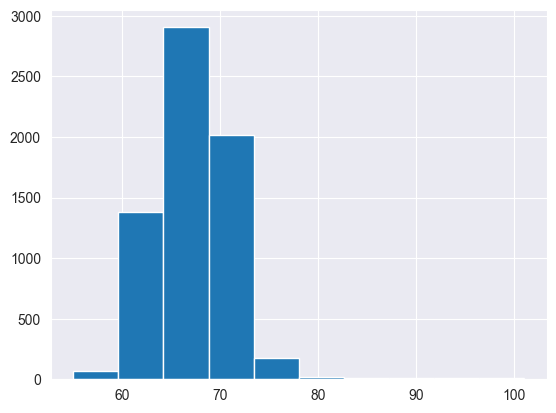

In [32]:
df['Exam_Score'].hist() #Y-axis = frequency of students in that range
                        #X-axis = exam score range

In [6]:
#feature engineering
df['Effort'] = df['Hours_Studied'] * df['Attendance']

In [7]:
#define target and features
y = df['Exam_Score']
X = df[['Hours_Studied','Attendance','Sleep_Hours','Effort']]

In [8]:
X_train,X_val,y_train,y_val = train_test_split(X,y)

In [9]:
#With DecisionTreeRegressor
model = DecisionTreeRegressor(random_state = 1)
model.fit(X_train,y_train)
predictions = model.predict(X_val)
dt_mae = mean_absolute_error(y_val,predictions)
print(dt_mae)

2.2344769687536035


In [10]:
#With Random Forest Regressor
model1 = RandomForestRegressor(random_state = 1)
model1.fit(X_train,y_train)
predictions1 = model1.predict(X_val)
mean_absolute_error(y_val,predictions1)

1.9019405570817893

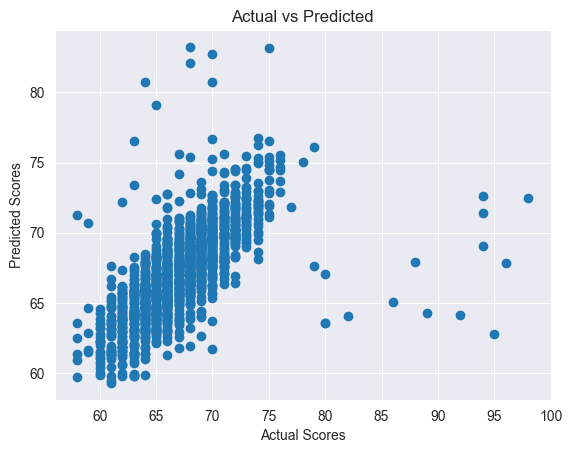

In [11]:
#Actual scores vs Predicted Scores
plt.scatter(y_val,predictions1) #scatter plot with y_val and predictions from Random Forest Regressor in inputs
plt.xlabel('Actual Scores') #name of x-axis
plt.ylabel('Predicted Scores') #name of y-axis
plt.title('Actual vs Predicted') #title of graph
plt.show()

In [16]:
# Now with more features
df["Balance"] = df["Hours_Studied"] / df["Sleep_Hours"]
df["Productivity"] = df["Hours_Studied"] * (df["Sleep_Hours"]/24)
X = df[[
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Effort",
    "Balance",
    "Productivity"
]]
X_train,X_val,y_train,y_val = train_test_split(X,y)
model2 = RandomForestRegressor(random_state = 50)
model2.fit(X_train,y_train)
predictions2 = model2.predict(X_val)
rf_mae = mean_absolute_error(y_val,predictions2)
print(f'MAE with Random Forest: {rf_mae}')

MAE with Random Forest: 1.90759802772893


In [15]:
#Tuning the Random Forest Regressor
for i in [50,100,200,250,300,1000]:
    model3 = RandomForestRegressor(n_estimators = i,random_state = 42,max_depth = 10)
    model3.fit(X_train,y_train)
    predictions3 = model3.predict(X_val)
    print(f'n_estimators = {i},MAE: {mean_absolute_error(y_val,predictions3)}')

n_estimators = 50,MAE: 1.7588139396989575
n_estimators = 100,MAE: 1.7478339623855652
n_estimators = 200,MAE: 1.7440732463173003
n_estimators = 250,MAE: 1.743692346935609
n_estimators = 300,MAE: 1.744676617168733
n_estimators = 1000,MAE: 1.7442905959058135


In [17]:
#since n_estimators = 1000 gives lowest MAE
model4 = RandomForestRegressor(n_estimators = 1000,random_state = 42,max_depth = 15)
model4.fit(X_train,y_train)
predictions4 = model3.predict(X_val)
tuned_rf_mae = mean_absolute_error(y_val,predictions4)
print(f'MAE of tuned Random Forest = {tuned_rf_mae}')

MAE of tuned Random Forest = 1.4110160203786242


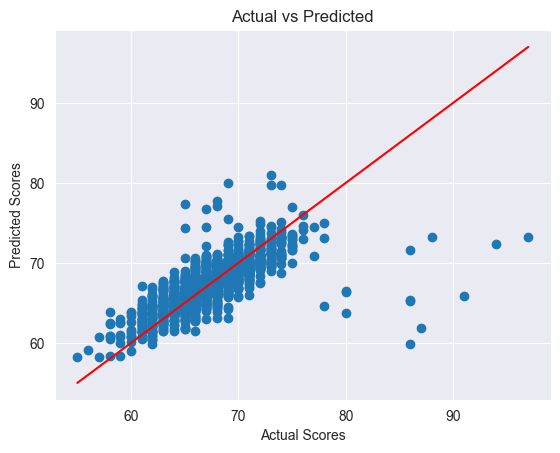

In [43]:
plt.scatter(y_val,predictions4)
plt.plot([y_val.min(), y_val.max()], #Adds a line y = x with red colour
         [y_val.min(), y_val.max()],
         color='red')
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted')
plt.show()

In [44]:
#The model performs reasonably well for mid-range values but tends to underestimate higher exam scores, indicating limitations in capturing extreme patterns.

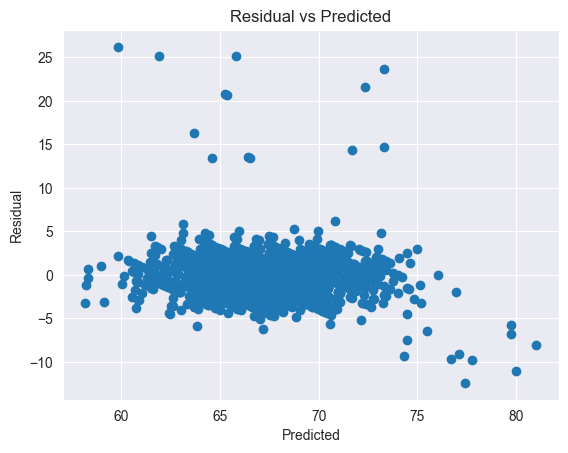

In [45]:
#Residual Analysis
residual = y_val - predictions4 #predictions from n_estimations = 1000 random forest regressor
plt.scatter(predictions4,residual)
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Residual vs Predicted')
plt.show()

In [46]:
#Most of the scatter points are around the zero means the model is predicting the results quite good. For residual > 20, the student performed greater than the model predicted. For predicted > 80, the model overpredicted the performance of students.

In [18]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_val)
lr_mae = mean_absolute_error(y_val, lr_preds)
print(f'MAE with Linear Regression: {lr_mae}')

MAE with Linear Regression: 1.6198303042657203


In [20]:
#compare different models
results = pd.DataFrame({"MAE": [dt_mae, tuned_rf_mae, lr_mae]}, index=["Decision Tree", "Random Forest", "Linear Regression"])

results = results.sort_values(by="MAE")

print(results)

                        MAE
Random Forest      1.411016
Linear Regression  1.619830
Decision Tree      2.234477


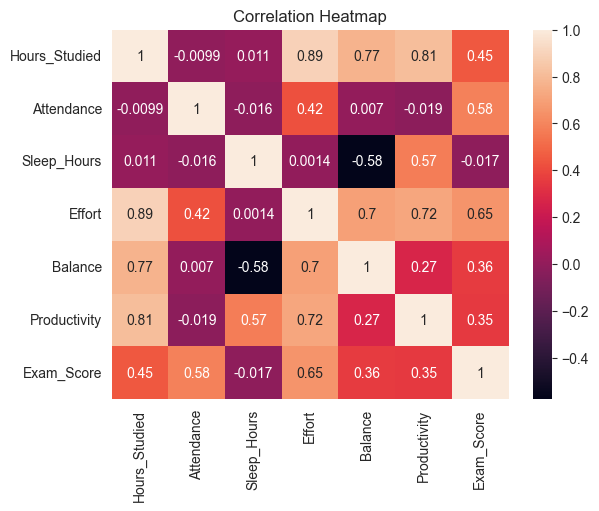

In [68]:
#correlation heatmap
features = df[[
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Effort",
    "Balance",
    "Productivity",
    "Exam_Score"
]]
sns.heatmap(features.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#key features of this correlation heatmap- for example looking at exma score row, effort has an correlation of 0.65 with exam scores which means effort and exam scores have a strong correlation, while hours studied has only 0.45 meaning the exam score doesnt depend much on the amount of time spent behind a book

Hours_Studied 0.018524350004916052
Attendance 0.23970345923520567
Sleep_Hours 0.02272969161262755
Effort 0.5676703161493554
Balance 0.07243882264269913
Productivity 0.0789333603551963


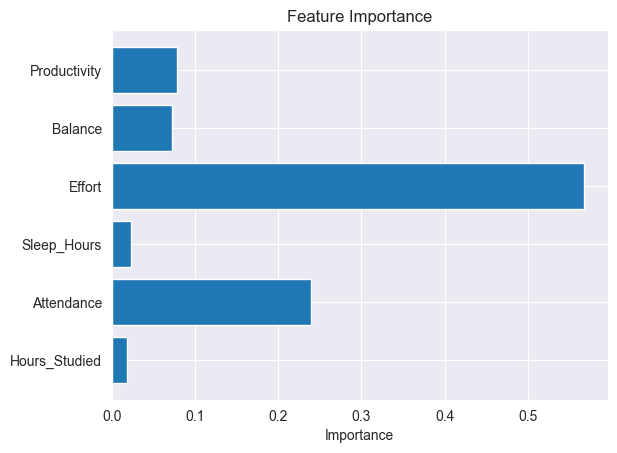

In [73]:
#Feature Importance
for name, val in zip(X.columns, model4.feature_importances_):
    print(name, val)
plt.barh(X.columns, model4.feature_importances_)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [ ]:
#Effort has a feature importance >0.5 which means it is the most important feature for predicting Exam score